# Airbnb Price Prediction in Tokyo

This notebook predicts the nightly price of an Airbnb listing in Tokyo. It follows the four steps suggested in the project description and combines tabular, spatial, text and image information.

The target is `log(price)`. All models use the same 80/20 train-test split. The test set remains untouched until the final evaluation, and model selection is performed on a validation subset of the training data.

In [2]:
%matplotlib inline

from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from catboost import Pool
from IPython.display import Markdown, display
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import airbnb_project as project

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style = "whitegrid", context = "notebook")
plt.rcParams["figure.figsize"] = (10, 5)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
if not use_cuda:
    raise RuntimeError("This project notebook expects a CUDA GPU.")
torch.set_float32_matmul_precision("high")

DATA_DIR = Path("data")
RANDOM_STATE = 42

print("Using device", device)
print(torch.cuda.get_device_name(device))

Using device cuda:0
NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1. Data Cleaning & Preparation

### 1.1 Load the Inside Airbnb snapshot

The listing file provides one current nightly price per listing. Reviews supply additional text. Calendar data is available locally, but it is not joined to the target because the objective here is the listing-level price contained in the snapshot.

In [3]:
LISTINGS_PATH = DATA_DIR / "listings.csv.gz"
REVIEWS_PATH = DATA_DIR / "reviews.csv.gz"
CALENDAR_PATH = DATA_DIR / "calendar.csv.gz"

required_files = [LISTINGS_PATH, REVIEWS_PATH, CALENDAR_PATH]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing project files: {missing_files}")

listings = pd.read_csv(LISTINGS_PATH, low_memory = False)

pd.DataFrame({
    "File": [path.name for path in required_files],
    "Available": [path.exists() for path in required_files],
    "Size in MB": [path.stat().st_size / 1024 ** 2 for path in required_files],
})

,File,Available,Size in MB
0,listings.csv.gz,True,16.391675
1,reviews.csv.gz,True,121.355387
2,calendar.csv.gz,True,23.149225


### 1.2 Clean the target and define the train-test split

In [4]:
data = project.clean_listings(listings)

train_index, test_index = train_test_split(
    data.index,
    test_size = 0.20,
    random_state = RANDOM_STATE,
)
y_train = data.loc[train_index, "log_price"]
y_test = data.loc[test_index, "log_price"]

pd.DataFrame({
    "Sample": ["Raw listings", "Positive observed prices", "Training", "Test"],
    "Rows": [len(listings), len(data), len(train_index), len(test_index)],
})

,Sample,Rows
0,Raw listings,27945
1,Positive observed prices,25480
2,Training,20384
3,Test,5096


### 1.3 Univariate exploration of `price`

In [5]:
price = data["price_numeric"]
log_price = data["log_price"]

target_summary = pd.DataFrame({
    "Variable": ["price", "log(price)"],
    "Mean": [price.mean(), log_price.mean()],
    "Variance": [price.var(ddof = 0), log_price.var(ddof = 0)],
    "Standard deviation": [price.std(ddof = 0), log_price.std(ddof = 0)],
    "Skewness": [price.skew(), log_price.skew()],
    "Median": [price.median(), log_price.median()],
    "99% quantile": [price.quantile(0.99), log_price.quantile(0.99)],
})
target_summary

,Variable,Mean,Variance,Standard deviation,Skewness,Median,99% quantile
0,price,24781.880926,6.062837e+09,77864.223239,85.069151,16200.000000,148912.96000
1,log(price),9.765066,4.570529e-01,0.676057,1.095535,9.692767,11.91111


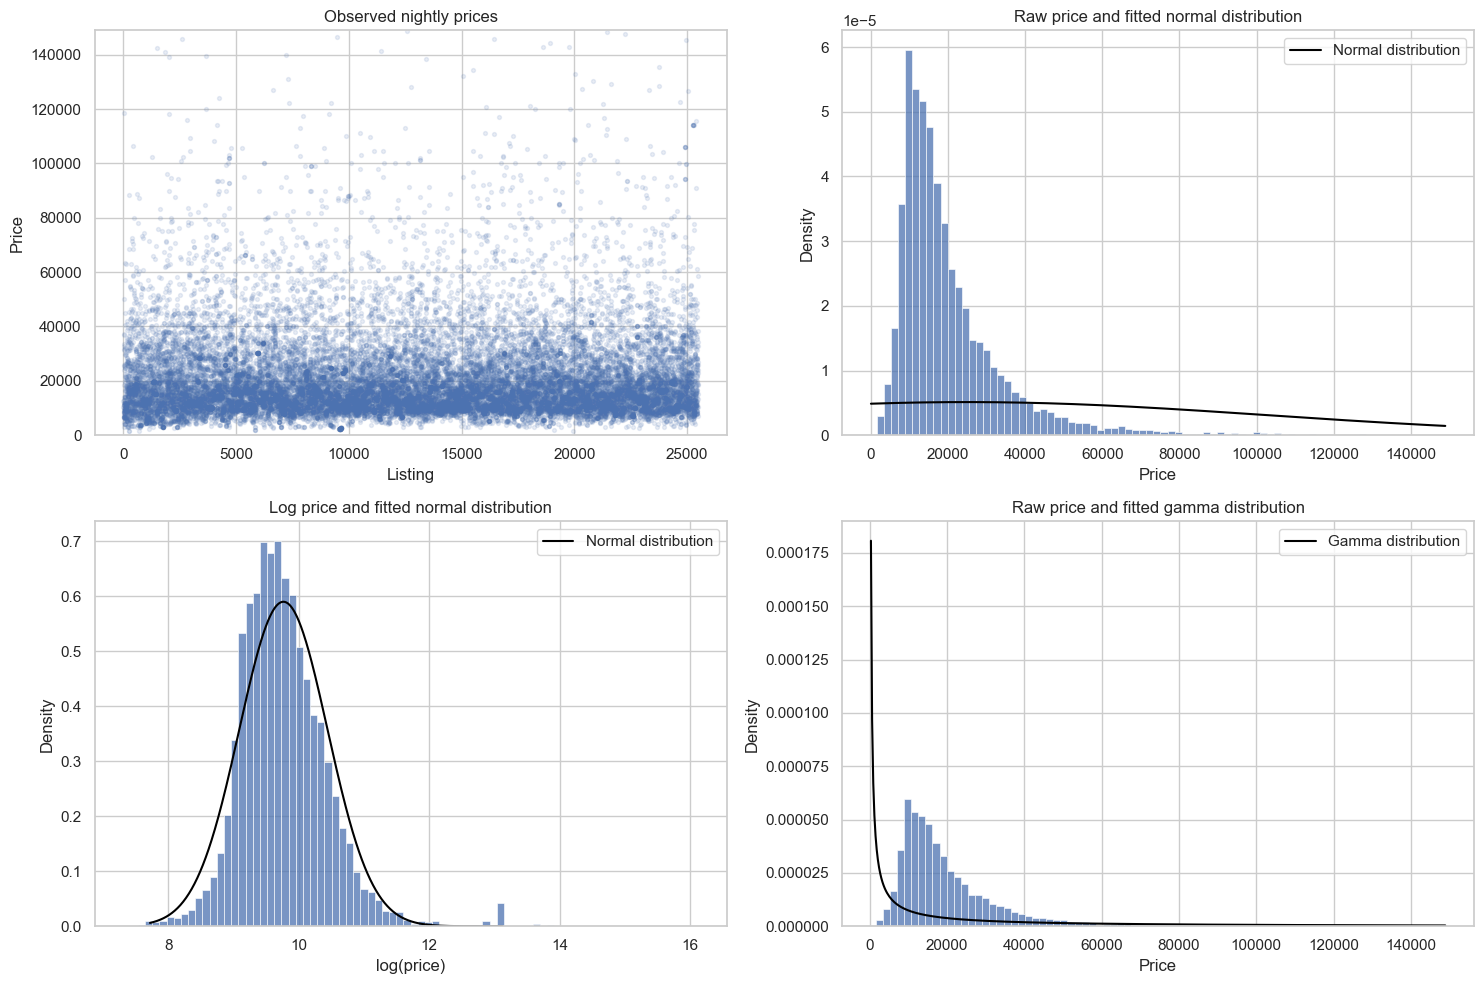

In [6]:
raw_mean = price.mean()
raw_variance = price.var(ddof = 0)
log_mean = log_price.mean()
log_standard_deviation = log_price.std(ddof = 0)
gamma_shape = raw_mean ** 2 / raw_variance
gamma_scale = raw_variance / raw_mean

raw_limit = price.quantile(0.99)
raw_grid = np.linspace(0, raw_limit, 500)
log_grid = np.linspace(log_price.quantile(0.001), log_price.quantile(0.999), 500)

fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes[0, 0].scatter(np.arange(len(price)), price, alpha = 0.12, s = 8)
axes[0, 0].set(
    title = "Observed nightly prices",
    xlabel = "Listing",
    ylabel = "Price",
    ylim = (0, raw_limit),
)

sns.histplot(price[price <= raw_limit], bins = 80, stat = "density", ax = axes[0, 1])
axes[0, 1].plot(
    raw_grid,
    stats.norm.pdf(raw_grid, loc = raw_mean, scale = np.sqrt(raw_variance)),
    color = "black",
    label = "Normal distribution",
)
axes[0, 1].set(title = "Raw price and fitted normal distribution", xlabel = "Price")
axes[0, 1].legend()

sns.histplot(log_price, bins = 80, stat = "density", ax = axes[1, 0])
axes[1, 0].plot(
    log_grid,
    stats.norm.pdf(log_grid, loc = log_mean, scale = log_standard_deviation),
    color = "black",
    label = "Normal distribution",
)
axes[1, 0].set(title = "Log price and fitted normal distribution", xlabel = "log(price)")
axes[1, 0].legend()

sns.histplot(price[price <= raw_limit], bins = 80, stat = "density", ax = axes[1, 1])
axes[1, 1].plot(
    raw_grid,
    stats.gamma.pdf(raw_grid, a = gamma_shape, loc = 0, scale = gamma_scale),
    color = "black",
    label = "Gamma distribution",
)
axes[1, 1].set(title = "Raw price and fitted gamma distribution", xlabel = "Price")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The raw target is extremely right-skewed. A gamma distribution respects positive support, but it still does not capture the pronounced price clusters. The logarithm substantially reduces skewness and makes squared-error regression more stable. We therefore model `log(price)` without deleting expensive listings.

### 1.4 High-price clusters and the value 500,000

In [7]:
high_price_counts = (
    price.loc[price >= 100_000]
    .value_counts()
    .rename_axis("Exact price")
    .reset_index(name = "Listings")
    .sort_values(["Listings", "Exact price"], ascending = [False, False])
)

profile_columns = [
    "accommodates",
    "bedrooms",
    "beds",
    "minimum_nights",
    "number_of_reviews",
]
exact_500k = data["price_numeric"].eq(500_000)
profile_500k = pd.DataFrame({
    "Group": ["Price = 500,000", "Other listings"],
    "Listings": [exact_500k.sum(), (~exact_500k).sum()],
    **{
        f"Median {column}": [
            data.loc[exact_500k, column].median(),
            data.loc[~exact_500k, column].median(),
        ]
        for column in profile_columns
    },
})

display(high_price_counts.head(12))
display(profile_500k)

,Exact price,Listings
0,500000.0,108
1,400000.0,20
2,100000.0,10
6,799999.0,6
4,460000.0,6
3,150000.0,6
5,114286.0,6
7,179983.0,5
9,180949.0,4
8,155429.0,4


,Group,Listings,Median accommodates,Median bedrooms,Median beds,Median minimum_nights,Median number_of_reviews
0,"Price = 500,000",108,3.0,1.0,2.0,30.0,0.0
1,Other listings,25372,4.0,1.0,2.0,2.0,16.0


Repeated round values, especially 500,000, are too concentrated to treat as ordinary continuous variation. They may combine genuine luxury listings with placeholder or capped prices. The log transformation limits their leverage, while the final section reports a sensitivity analysis that excludes these extreme test observations.

## 2. Feature Engineering

Feature construction is implemented in `airbnb_project.py`. This keeps the notebook focused on modeling decisions while retaining an explicit, reusable pipeline. Image downloading and CLIP embedding extraction remain separate resumable scripts because they are expensive one-time preparation steps.

### 2.1 Tabular, categorical and spatial features

In [8]:
design = project.build_design_matrices(data, train_index, test_index)
X_train_linear = design["train"]
X_test_linear = design["test"]

feature_overview = pd.DataFrame({
    "Feature block": [
        "Categorical variables",
        "Log-transformed numeric variables",
        "Other numeric variables",
        "One-hot and spline features",
        "Interaction features",
        "Final design matrix",
        "Group-wise components",
    ],
    "Count": [
        len(project.LINEAR_CATEGORICAL_COLUMNS),
        len(project.LINEAR_LOG_NUMERIC_COLUMNS),
        len(project.LINEAR_PLAIN_NUMERIC_COLUMNS),
        design["base_feature_count"],
        design["interaction_count"],
        X_train_linear.shape[1],
        len(design["groups"]),
    ],
})
feature_overview

,Feature block,Count
0,Categorical variables,42
1,Log-transformed numeric variables,6
2,Other numeric variables,4
3,One-hot and spline features,313
4,Interaction features,704
5,Final design matrix,1017
6,Group-wise components,83


Review scores are encoded as data-driven buckets rather than as linear numbers. Each score bucket interacts with the review counts, because a rating based on many reviews is more informative than the same rating based on one review. Dummy coefficients belonging to one original variable form one component in the group-wise boosting model.

### 2.2 Listing descriptions and recent review text

In [9]:
reviews = pd.read_csv(
    REVIEWS_PATH,
    usecols = ["listing_id", "date", "comments"],
    low_memory = False,
)
review_text, review_text_count = project.aggregate_review_text(reviews)
data = project.add_text_features(data, review_text, review_text_count)

text_coverage = pd.DataFrame({
    "Text feature": project.TEXT_COLUMNS,
    "Available share": [
        data[column].ne("missing text").mean() for column in project.TEXT_COLUMNS
    ],
    "Median characters": [data[column].str.len().median() for column in project.TEXT_COLUMNS],
})
text_coverage

,Text feature,Available share,Median characters
0,listing_text,1.000000,1099.0
1,reviews_text,0.862755,1230.0
2,amenities_text,0.999961,422.0


In [10]:
catboost_tabular = project.prepare_catboost_data(data)
catboost_text = project.prepare_catboost_data(data, include_text = True)

X_catboost_train = catboost_tabular.loc[train_index]
X_catboost_test = catboost_tabular.loc[test_index]
X_text_train = catboost_text.loc[train_index]
X_text_test = catboost_text.loc[test_index]

fit_positions, validation_positions = train_test_split(
    np.arange(len(train_index)),
    test_size = 0.20,
    random_state = RANDOM_STATE,
)

tfidf = project.build_tfidf_features(
    X_text_train,
    X_text_test,
    fit_positions,
    validation_positions,
)

pd.DataFrame({
    "Representation": ["Word TF-IDF", "Character TF-IDF", "Truncated SVD"],
    "Size": [
        tfidf["word_vocabulary"],
        tfidf["character_vocabulary"],
        len(tfidf["columns"]),
    ],
})

,Representation,Size
0,Word TF-IDF,12000
1,Character TF-IDF,12000
2,Truncated SVD,128


### 2.3 Main-image CLIP prompt features

The main images and their 512-dimensional CLIP embeddings were prepared once with `download_listing_images.py` and `extract_clip_embeddings.py`. The notebook loads this cache and converts each image into 15 interpretable similarities to text prompts. This is more compact than passing all 512 embedding dimensions to CatBoost.

In [11]:
IMAGE_MANIFEST_PATH = DATA_DIR / "image_manifest.csv"
IMAGE_EMBEDDING_PATH = DATA_DIR / "clip_main_image_embeddings.npz"

if not IMAGE_MANIFEST_PATH.exists() or not IMAGE_EMBEDDING_PATH.exists():
    raise FileNotFoundError(
        "Run download_listing_images.py and extract_clip_embeddings.py before this notebook."
    )

clip_prompt_features, prompt_map = project.build_clip_prompt_features(
    data,
    IMAGE_MANIFEST_PATH,
    IMAGE_EMBEDDING_PATH,
    device,
)

pd.DataFrame({
    "Image representation": ["Cached CLIP embedding", "CLIP prompt similarities"],
    "Dimensions": [512, len(project.IMAGE_PROMPTS)],
    "Listing coverage": [
        clip_prompt_features["clip_image_available"].mean(),
        clip_prompt_features["clip_image_available"].mean(),
    ],
})

,Image representation,Dimensions,Listing coverage
0,Cached CLIP embedding,512,0.951374
1,CLIP prompt similarities,15,0.951374


## 3. Modeling & Tuning

Every reported score is calculated on the same held-out test set. MSE is measured on `log(price)`. CatBoost internally names its squared-error objective `RMSE`; only the API name remains RMSE, while reported values are squared to obtain MSE.

In [12]:
model_metrics = []
test_predictions = {}
training_times = {}

def store_result(model_name, prediction, seconds):
    test_predictions[model_name] = np.asarray(prediction)
    training_times[model_name] = seconds
    model_metrics.append(project.evaluate_predictions(model_name, y_test, prediction))

### 3.1 Linear regression

In [13]:
start = perf_counter()
linear_model = LinearRegression(n_jobs = -1)
linear_model.fit(X_train_linear, y_train)
linear_prediction = linear_model.predict(X_test_linear)
linear_seconds = perf_counter() - start

store_result("Linear regression", linear_prediction, linear_seconds)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
Linear regression,0.202027,0.286967,0.549922,8960.066952,3386.662844


### 3.2 Group-wise component boosting

In [14]:
start = perf_counter()
groupwise_validation_model = project.fit_groupwise_boosting(
    X_train_linear[fit_positions],
    y_train.iloc[fit_positions],
    design["groups"],
    X_valid = X_train_linear[validation_positions],
    y_valid = y_train.iloc[validation_positions],
    max_iter = 5_0000,
    learning_rate = 0.01,
    patience = 300,
    min_delta = 1e-5,
    device = device,
)
best_groupwise_iteration = groupwise_validation_model["best_iteration"]

groupwise_model = project.fit_groupwise_boosting(
    X_train_linear,
    y_train,
    design["groups"],
    max_iter = best_groupwise_iteration,
    learning_rate = 0.01,
    device = device,
)
groupwise_prediction = project.predict_groupwise_boosting(groupwise_model, X_test_linear)
groupwise_seconds = perf_counter() - start

store_result("Group-wise component boosting", groupwise_prediction, groupwise_seconds)
print("Best validation iteration", best_groupwise_iteration)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

Best validation iteration 16033


,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
Group-wise component boosting,0.198484,0.286117,0.557817,8941.487034,3458.321708


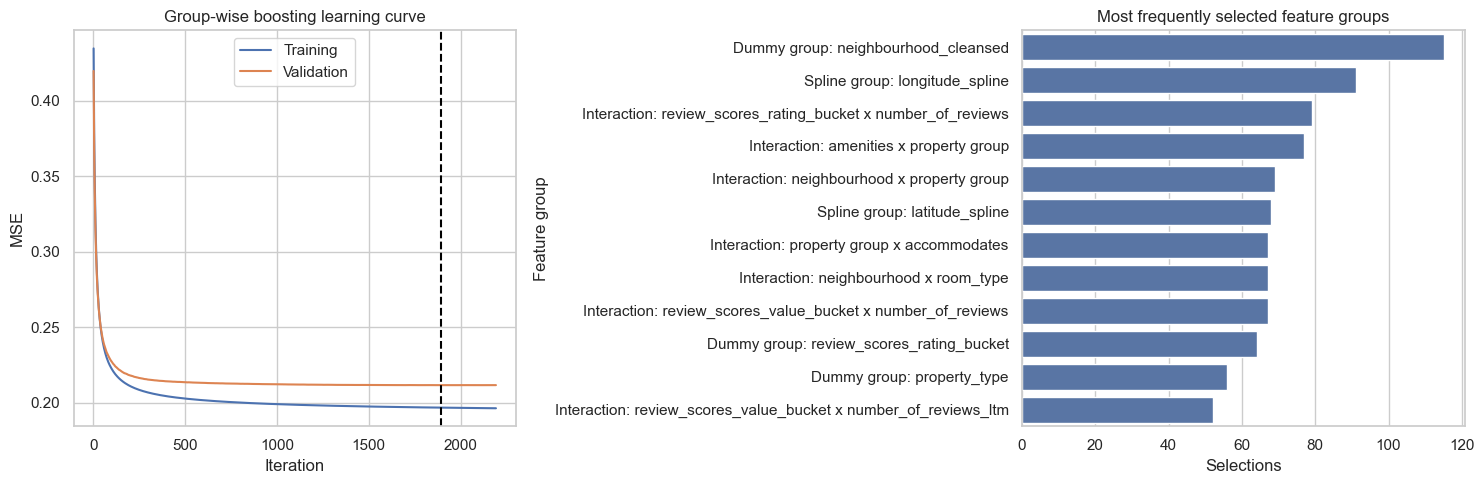

In [14]:
iterations = np.arange(1, groupwise_validation_model["iterations_run"] + 1)
selected_groups = (
    pd.Series(groupwise_model["selected_groups"], name = "Selections")
    .value_counts()
    .rename_axis("Feature group")
    .reset_index(name = "Selections")
)

fig, axes = plt.subplots(1, 2, figsize = (15, 5))
axes[0].plot(iterations, groupwise_validation_model["train_loss"], label = "Training")
axes[0].plot(iterations, groupwise_validation_model["validation_loss"], label = "Validation")
axes[0].axvline(best_groupwise_iteration, color = "black", linestyle = "--")
axes[0].set(title = "Group-wise boosting learning curve", xlabel = "Iteration", ylabel = "MSE")
axes[0].legend()

sns.barplot(data = selected_groups.head(12), x = "Selections", y = "Feature group", ax = axes[1])
axes[1].set(title = "Most frequently selected feature groups")
plt.tight_layout()
plt.show()

### 3.3 Histogram Gradient Boosting

In [15]:
start = perf_counter()
X_train_dense = X_train_linear.toarray().astype(np.float32)
X_test_dense = X_test_linear.toarray().astype(np.float32)

histogram_model = HistGradientBoostingRegressor(
    learning_rate = 0.05,
    max_iter = 1_000,
    max_leaf_nodes = 31,
    min_samples_leaf = 20,
    l2_regularization = 1.0,
    early_stopping = True,
    validation_fraction = 0.20,
    n_iter_no_change = 20,
    tol = 1e-4,
    scoring = "loss",
    random_state = RANDOM_STATE,
)
histogram_model.fit(X_train_dense, y_train)
histogram_prediction = histogram_model.predict(X_test_dense)
histogram_seconds = perf_counter() - start

store_result("Histogram Gradient Boosting", histogram_prediction, histogram_seconds)
print("Boosting iterations", histogram_model.n_iter_)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

Boosting iterations 437


,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
Histogram Gradient Boosting,0.142435,0.245345,0.682683,8009.683046,2764.539992


### 3.4 CatBoost with tabular features

In [16]:
tabular_fit_pool = Pool(
    X_catboost_train.iloc[fit_positions],
    y_train.iloc[fit_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
)
tabular_validation_pool = Pool(
    X_catboost_train.iloc[validation_positions],
    y_train.iloc[validation_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
)
tabular_test_pool = Pool(
    X_catboost_test,
    y_test,
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
)

catboost_tabular_model, catboost_tabular_seconds = project.fit_catboost(
    "CatBoost tabular",
    tabular_fit_pool,
    tabular_validation_pool,
)
catboost_tabular_prediction = catboost_tabular_model.predict(tabular_test_pool)
store_result("CatBoost tabular", catboost_tabular_prediction, catboost_tabular_seconds)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

0:	learn: 0.6555534	test: 0.6446743	best: 0.6446743 (0)	total: 86.4ms	remaining: 5m 45s


200:	learn: 0.3649226	test: 0.4096149	best: 0.4096149 (200)	total: 1.72s	remaining: 32.5s


400:	learn: 0.3159877	test: 0.3865910	best: 0.3865910 (400)	total: 3.2s	remaining: 28.7s


600:	learn: 0.2835038	test: 0.3759172	best: 0.3759172 (600)	total: 4.81s	remaining: 27.2s


800:	learn: 0.2591683	test: 0.3707878	best: 0.3707878 (800)	total: 6.35s	remaining: 25.4s


...

3400:	learn: 0.1195739	test: 0.3513643	best: 0.3513595 (3392)	total: 28.9s	remaining: 5.1s


3600:	learn: 0.1149218	test: 0.3511074	best: 0.3511074 (3600)	total: 30.8s	remaining: 3.41s


3800:	learn: 0.1107091	test: 0.3510339	best: 0.3510269 (3796)	total: 32.4s	remaining: 1.7s


3999:	learn: 0.1065190	test: 0.3507128	best: 0.3506531 (3969)	total: 33.9s	remaining: 0us
bestTest = 0.3506530804
bestIteration = 3969
Shrink model to first 3970 iterations.
CatBoost tabular: 0.58 minutes
Best iteration: 3970
Validation MSE: 0.122958


,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
CatBoost tabular,0.117092,0.21739,0.739141,6904.471536,2382.007044


### 3.5 CatBoost with native text features

In [17]:
text_fit_pool = Pool(
    X_text_train.iloc[fit_positions],
    y_train.iloc[fit_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
    text_features = project.TEXT_COLUMNS,
)
text_validation_pool = Pool(
    X_text_train.iloc[validation_positions],
    y_train.iloc[validation_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
    text_features = project.TEXT_COLUMNS,
)
text_test_pool = Pool(
    X_text_test,
    y_test,
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
    text_features = project.TEXT_COLUMNS,
)

catboost_text_model, catboost_text_seconds = project.fit_catboost(
    "CatBoost native text",
    text_fit_pool,
    text_validation_pool,
    feature_calcers = ["BoW:top_tokens_count=4000"],
)
catboost_text_prediction = catboost_text_model.predict(text_test_pool)
store_result("CatBoost native text", catboost_text_prediction, catboost_text_seconds)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

0:	learn: 0.6555534	test: 0.6446743	best: 0.6446743 (0)	total: 78.7ms	remaining: 5m 14s


200:	learn: 0.3342395	test: 0.3870414	best: 0.3869923 (199)	total: 3.47s	remaining: 1m 5s


400:	learn: 0.2932273	test: 0.3712677	best: 0.3712677 (400)	total: 6.85s	remaining: 1m 1s


600:	learn: 0.2643508	test: 0.3624757	best: 0.3624570 (599)	total: 10.2s	remaining: 57.5s


800:	learn: 0.2422537	test: 0.3566570	best: 0.3566570 (800)	total: 15.8s	remaining: 1m 3s


...

3600:	learn: 0.1055393	test: 0.3369777	best: 0.3369756 (3598)	total: 1m 2s	remaining: 6.97s


3800:	learn: 0.1009403	test: 0.3367293	best: 0.3367085 (3782)	total: 1m 6s	remaining: 3.49s


3999:	learn: 0.0968550	test: 0.3365362	best: 0.3365224 (3994)	total: 1m 10s	remaining: 0us
bestTest = 0.3365224458
bestIteration = 3994
Shrink model to first 3995 iterations.


CatBoost native text: 1.31 minutes
Best iteration: 3995
Validation MSE: 0.113247


,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
CatBoost native text,0.104848,0.202293,0.766418,6230.341814,2159.446356


### 3.6 CatBoost with TF-IDF and Truncated SVD

In [18]:
tfidf_structured_columns = list(catboost_tabular.columns) + project.TEXT_NUMERIC_COLUMNS

X_tfidf_fit = pd.concat([
    X_text_train.iloc[fit_positions][tfidf_structured_columns],
    tfidf["fit"],
], axis = 1)
X_tfidf_validation = pd.concat([
    X_text_train.iloc[validation_positions][tfidf_structured_columns],
    tfidf["validation"],
], axis = 1)
X_tfidf_test = pd.concat([
    X_text_test[tfidf_structured_columns],
    tfidf["test"],
], axis = 1)

tfidf_fit_pool = Pool(
    X_tfidf_fit,
    y_train.iloc[fit_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
)
tfidf_validation_pool = Pool(
    X_tfidf_validation,
    y_train.iloc[validation_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
)
tfidf_test_pool = Pool(
    X_tfidf_test,
    y_test,
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
)

catboost_tfidf_model, catboost_tfidf_seconds = project.fit_catboost(
    "CatBoost TF-IDF",
    tfidf_fit_pool,
    tfidf_validation_pool,
)
catboost_tfidf_prediction = catboost_tfidf_model.predict(tfidf_test_pool)
store_result("CatBoost TF-IDF", catboost_tfidf_prediction, catboost_tfidf_seconds)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

0:	learn: 0.6555534	test: 0.6446743	best: 0.6446743 (0)	total: 14ms	remaining: 55.8s


200:	learn: 0.3186661	test: 0.3832714	best: 0.3832714 (200)	total: 2.6s	remaining: 49.1s


400:	learn: 0.2617189	test: 0.3677932	best: 0.3677932 (400)	total: 5.26s	remaining: 47.2s


600:	learn: 0.2198405	test: 0.3609084	best: 0.3609084 (600)	total: 7.66s	remaining: 43.3s


800:	learn: 0.1885622	test: 0.3573569	best: 0.3573232 (797)	total: 9.87s	remaining: 39.4s


...

2800:	learn: 0.0536131	test: 0.3480650	best: 0.3480650 (2800)	total: 43.1s	remaining: 18.5s


3000:	learn: 0.0486142	test: 0.3480312	best: 0.3479973 (2981)	total: 46.8s	remaining: 15.6s


bestTest = 0.347997329
bestIteration = 2981
Shrink model to first 2982 iterations.


CatBoost TF-IDF: 0.83 minutes
Best iteration: 2982
Validation MSE: 0.121102


,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
CatBoost TF-IDF,0.113117,0.213959,0.747996,6292.913893,2376.517468


### 3.7 CatBoost with native text and CLIP prompt features

In [19]:
X_prompt_train = pd.concat([
    X_text_train,
    clip_prompt_features.loc[train_index],
], axis = 1)
X_prompt_test = pd.concat([
    X_text_test,
    clip_prompt_features.loc[test_index],
], axis = 1)

prompt_fit_pool = Pool(
    X_prompt_train.iloc[fit_positions],
    y_train.iloc[fit_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
    text_features = project.TEXT_COLUMNS,
)
prompt_validation_pool = Pool(
    X_prompt_train.iloc[validation_positions],
    y_train.iloc[validation_positions],
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
    text_features = project.TEXT_COLUMNS,
)
prompt_test_pool = Pool(
    X_prompt_test,
    y_test,
    cat_features = project.CATBOOST_CATEGORICAL_COLUMNS,
    text_features = project.TEXT_COLUMNS,
)

catboost_prompt_model, catboost_prompt_seconds = project.fit_catboost(
    "CatBoost native text and CLIP prompts",
    prompt_fit_pool,
    prompt_validation_pool,
    feature_calcers = ["BoW:top_tokens_count=4000"],
)
catboost_prompt_prediction = catboost_prompt_model.predict(prompt_test_pool)
store_result(
    "CatBoost native text and CLIP prompts",
    catboost_prompt_prediction,
    catboost_prompt_seconds,
)
pd.DataFrame([model_metrics[-1]]).set_index("Model")

0:	learn: 0.6555534	test: 0.6446743	best: 0.6446743 (0)	total: 85.8ms	remaining: 5m 42s


200:	learn: 0.3309660	test: 0.3841365	best: 0.3841365 (200)	total: 6.86s	remaining: 2m 9s


400:	learn: 0.2882807	test: 0.3676351	best: 0.3676351 (400)	total: 18.7s	remaining: 2m 48s


600:	learn: 0.2601269	test: 0.3590990	best: 0.3590990 (600)	total: 23.6s	remaining: 2m 13s


800:	learn: 0.2374203	test: 0.3532647	best: 0.3532647 (800)	total: 31.7s	remaining: 2m 6s


...

3600:	learn: 0.0925080	test: 0.3321854	best: 0.3321271 (3582)	total: 1m 38s	remaining: 10.9s


3800:	learn: 0.0874517	test: 0.3319383	best: 0.3319367 (3763)	total: 1m 43s	remaining: 5.42s


3999:	learn: 0.0828377	test: 0.3315119	best: 0.3315119 (3999)	total: 1m 48s	remaining: 0us
bestTest = 0.3315118534
bestIteration = 3999


CatBoost native text and CLIP prompts: 2.02 minutes
Best iteration: 4000
Validation MSE: 0.109900


,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
CatBoost native text and CLIP prompts,0.105467,0.203291,0.765041,6238.995562,2202.297348


### 3.8 Optional long-run comparison

The following two cells use identical 40,000-iteration settings for a fair text-only versus text-plus-image comparison. They are intentionally tagged `skip-execution` because they are the expensive final tuning runs.

In [ ]:
catboost_text_long_model, catboost_text_long_seconds = project.fit_catboost(
    "CatBoost native text, long run",
    text_fit_pool,
    text_validation_pool,
    iterations = 40_000,
    learning_rate = 0.05,
    early_stopping_rounds = 500,
    verbose = 500,
    feature_calcers = ["BoW:top_tokens_count=4000"],
)
catboost_text_long_prediction = catboost_text_long_model.predict(text_test_pool)
store_result(
    "CatBoost native text, long run",
    catboost_text_long_prediction,
    catboost_text_long_seconds,
)

In [ ]:
catboost_prompt_long_model, catboost_prompt_long_seconds = project.fit_catboost(
    "CatBoost native text and CLIP prompts, long run",
    prompt_fit_pool,
    prompt_validation_pool,
    iterations = 40_000,
    learning_rate = 0.05,
    early_stopping_rounds = 500,
    verbose = 500,
    feature_calcers = ["BoW:top_tokens_count=4000"],
)
catboost_prompt_long_prediction = catboost_prompt_long_model.predict(prompt_test_pool)
store_result(
    "CatBoost native text and CLIP prompts, long run",
    catboost_prompt_long_prediction,
    catboost_prompt_long_seconds,
)

## 4. Analysis & Reporting

### 4.1 Final comparison on the held-out test set

In [20]:
results = pd.DataFrame(model_metrics).set_index("Model")
results["Training time in minutes"] = pd.Series(training_times) / 60
results = results.sort_values("MSE log(price)")
results

,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price,Training time in minutes
Model,,,,,,
CatBoost native text,0.104848,0.202293,0.766418,6230.341814,2159.446356,1.309658
CatBoost native text and CLIP prompts,0.105467,0.203291,0.765041,6238.995562,2202.297348,2.021947
CatBoost TF-IDF,0.113117,0.213959,0.747996,6292.913893,2376.517468,0.833505
CatBoost tabular,0.117092,0.217390,0.739141,6904.471536,2382.007044,0.580522
Histogram Gradient Boosting,0.142435,0.245345,0.682683,8009.683046,2764.539992,0.593300
Group-wise component boosting,0.198252,0.285723,0.558332,8934.369636,3443.312059,0.110119
Linear regression,0.202027,0.286967,0.549922,8960.066952,3386.662844,0.090165


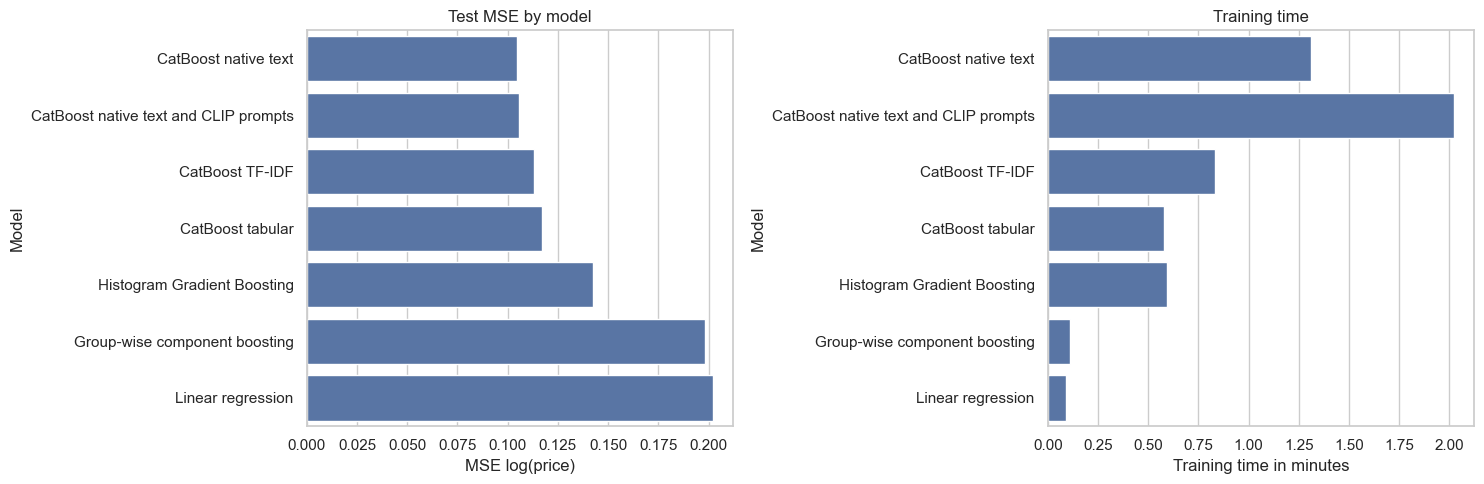

In [21]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))
sns.barplot(
    data = results.reset_index(),
    x = "MSE log(price)",
    y = "Model",
    ax = axes[0],
)
axes[0].set(title = "Test MSE by model")

sns.barplot(
    data = results.reset_index(),
    x = "Training time in minutes",
    y = "Model",
    ax = axes[1],
)
axes[1].set(title = "Training time")
plt.tight_layout()
plt.show()

### 4.2 Predictions and sensitivity to extreme prices

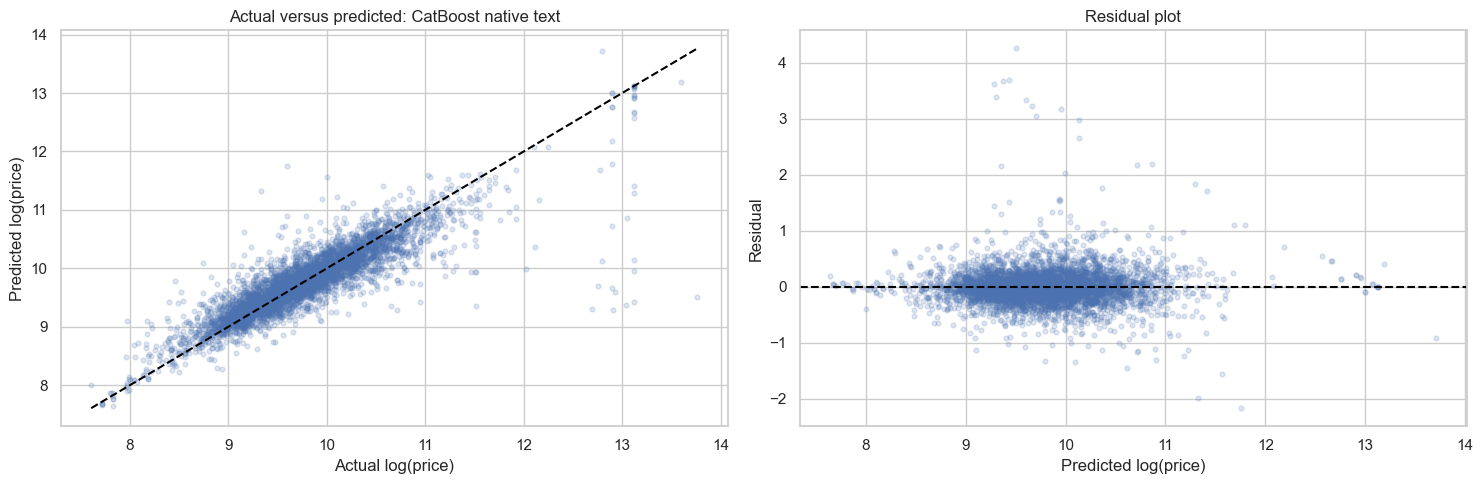

,MSE log(price),MAE log(price),R2 log(price),MAE price,Median AE price
Model,,,,,
CatBoost native text,0.104848,0.202293,0.766418,6230.341814,2159.446356
"CatBoost native text, price below 500,000",0.093834,0.199072,0.767939,5376.966482,2149.774362


In [22]:
best_model_name = results.index[0]
best_prediction = test_predictions[best_model_name]
lower = min(y_test.min(), best_prediction.min())
upper = max(y_test.max(), best_prediction.max())

fig, axes = plt.subplots(1, 2, figsize = (15, 5))
axes[0].scatter(y_test, best_prediction, alpha = 0.18, s = 12)
axes[0].plot([lower, upper], [lower, upper], color = "black", linestyle = "--")
axes[0].set(
    title = f"Actual versus predicted: {best_model_name}",
    xlabel = "Actual log(price)",
    ylabel = "Predicted log(price)",
)

residuals = y_test.to_numpy() - best_prediction
axes[1].scatter(best_prediction, residuals, alpha = 0.18, s = 12)
axes[1].axhline(0, color = "black", linestyle = "--")
axes[1].set(title = "Residual plot", xlabel = "Predicted log(price)", ylabel = "Residual")
plt.tight_layout()
plt.show()

test_price = data.loc[test_index, "price_numeric"].to_numpy()
regular_mask = test_price < 500_000
sensitivity = pd.DataFrame([
    project.evaluate_predictions(best_model_name, y_test, best_prediction),
    project.evaluate_predictions(
        f"{best_model_name}, price below 500,000",
        y_test.to_numpy()[regular_mask],
        best_prediction[regular_mask],
    ),
]).set_index("Model")
sensitivity

### 4.3 Feature importance and modality contribution

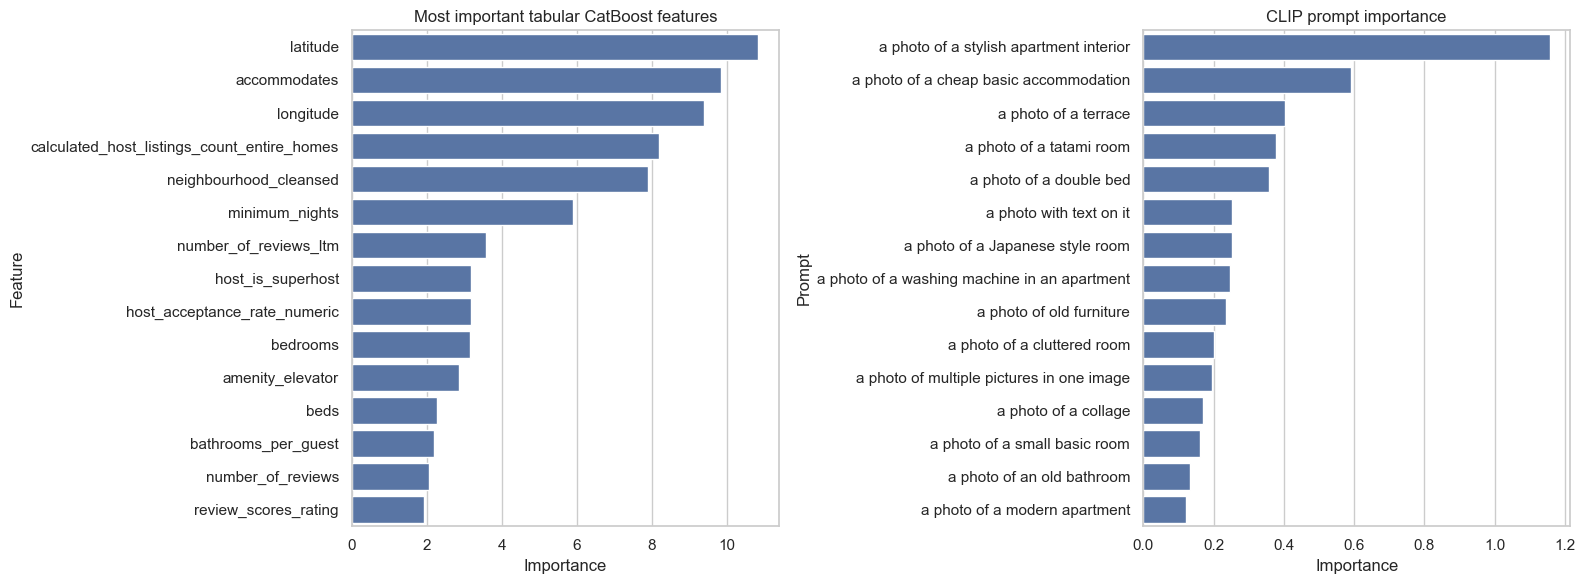

In [23]:
tabular_importance = pd.DataFrame({
    "Feature": X_catboost_train.columns,
    "Importance": catboost_tabular_model.get_feature_importance(tabular_fit_pool),
}).sort_values("Importance", ascending = False)

prompt_importance = pd.DataFrame({
    "Feature": X_prompt_train.columns,
    "Importance": catboost_prompt_model.get_feature_importance(prompt_fit_pool),
})
prompt_importance = prompt_importance.merge(prompt_map, on = "Feature", how = "inner")
prompt_importance = prompt_importance.sort_values("Importance", ascending = False)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))
sns.barplot(data = tabular_importance.head(15), x = "Importance", y = "Feature", ax = axes[0])
axes[0].set(title = "Most important tabular CatBoost features")
sns.barplot(data = prompt_importance, x = "Importance", y = "Prompt", ax = axes[1])
axes[1].set(title = "CLIP prompt importance")
plt.tight_layout()
plt.show()

In [24]:
tabular_mse = results.loc["CatBoost tabular", "MSE log(price)"]
text_mse = results.loc["CatBoost native text", "MSE log(price)"]
prompt_mse = results.loc["CatBoost native text and CLIP prompts", "MSE log(price)"]
best_row = results.iloc[0]

display(Markdown(f''' 
### 4.4 Conclusions

- **Best executed model:** {best_model_name} with test MSE **{best_row['MSE log(price)']:.4f}** and test R2 **{best_row['R2 log(price)']:.3f}**.
- Native text changes MSE from **{tabular_mse:.4f}** to **{text_mse:.4f}** relative to tabular CatBoost.
- Adding CLIP prompt similarities changes MSE from **{text_mse:.4f}** to **{prompt_mse:.4f}** relative to native text CatBoost.
- The linear and group-wise models remain useful transparent baselines, while tree boosting captures nonlinear thresholds and interactions more efficiently.
- The image contribution should be interpreted as incremental predictive information, not object recognition learned by CatBoost itself. CLIP performs the semantic image encoding before CatBoost receives the prompt similarities.
'''))

 
### 4.4 Conclusions

- **Best executed model:** CatBoost native text with test MSE **0.1048** and test R2 **0.766**.
- Native text changes MSE from **0.1171** to **0.1048** relative to tabular CatBoost.
- Adding CLIP prompt similarities changes MSE from **0.1048** to **0.1055** relative to native text CatBoost.
- The linear and group-wise models remain useful transparent baselines, while tree boosting captures nonlinear thresholds and interactions more efficiently.
- The image contribution should be interpreted as incremental predictive information, not object recognition learned by CatBoost itself. CLIP performs the semantic image encoding before CatBoost receives the prompt similarities.


### 4.5 Limitations and possible improvements

- The listing snapshot contains asking prices rather than completed transaction prices.
- Round extreme prices may include placeholders or caps. A future robustness analysis could model these listings separately.
- Review scores are missing systematically for new listings. A deployment model for new listings should therefore also be evaluated without review-derived features.
- Only the main listing image is used. Multiple images could be aggregated if a reliable image gallery source becomes available.
- Data from additional cities could improve generalization, but city should then be modeled explicitly and evaluation should include a city-held-out experiment.